<h1>ML basics</h1>
Deep learning works by performing large‑scale numerical computation on tensor (scalars, vectors, matrices and higher‑dimensional arrays). Getting comfortable with shape, rank, dtype and a few core operations (indexing, broadcasting, matmul, reductions) prevents most bugs when building models.

Import TensorFlow (GPU/CPU numerical engine + deep learning library) and NumPy (general numerical Python library). Print the TF version. Some behaviors (e.g., default dtypes) can vary across versions.

In [1]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)

TF: 2.20.0


Rank = number of axes (dimensions).  
scalar has rank 0 (shape=()) > a single number;  
vector rank 1 (shape=(3,));  
matrix rank 2 (shape=(2,2));  
tensor rank 3 (shape=(2,2,1)).  
Shape = size along each axis (batch, height, width...).

  
Your models understand only numbers and shapes. 

In [2]:
# 1) Scalars, vectors, matrices, tensors
scalar = tf.constant(7)  # rank-0
vector = tf.constant([10, 20, 30]) # rank-1
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank-2
tensor  = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3 (2x2x1)

print(scalar.shape, vector.shape, matrix.shape, tensor.shape)

() (3,) (2, 2) (2, 2, 1)


<i>Extra task:</i><br>
What’s the rank/shape of an RGB image with 32 images 64×64 pixels?

In [3]:
img_batch = tf.zeros([32, 64, 64, 3])  # 32 images, 64×64, RGB
print(img_batch.shape, img_batch.ndim) # (32, 64, 64, 3), rank=4

(32, 64, 64, 3) 4


tf.zeros([32, 64, 64, 3]) creates a new tensor of the given shape filled with zeros. In the context of images 0 means no intensity > a completely black pixel.<br><br>
So img_batch is a batch of 32 solid‑black images, each 64×64 with 3 color channels.

In [4]:
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4]) # float32 default
y = tf.constant([7, 10]) # int32 default
x16 = tf.cast(x, tf.float16) # reduced precision floats
y32 = tf.cast(y, tf.float32) # cast ints → floats

A dtype (data type) tells TensorFlow what kind of numbers a tensor stores, e.g., float32, float16, int32, or bool. It’s one of the three core properties of a tensor alongside shape and rank. The dtype you choose affects memory use and numerical precision, so it has practical consequences for speed and stability.
<br><br>
Casting changes dtype without changing shape. float16 halves memory but reduces precision. Good for speed on certain GPUs.

In [5]:
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7], [3, 4]])
last_col = rank2[:, -1] # column slice
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1)

: picks all rows. 
-1 selects the last column. last_col has shape (2,).

<b>Reshaping:</b>

expand_dims(..., -1) adds a new axis at the end: (2,2) > (2,2,1).<br>
squeeze(..., axis=-1) removes a size‑1 axis: back to (2,2).

In [6]:
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.], [3., 4.]])
print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


Basic ops: +, * operate per position. This is different from matrix multiplication (tf.matmul).

Matmul rule: For A @ B, the inner dimensions must match: (m×n) @ (n×p) -> (m×p). So you transpose Y (from (3×2) to (2×3)) to make 2 match 2.<br><br>
Matrix multiplication is central to neural networks. 

In [7]:
# 5) Matrix multiplication rules (inner dims match)
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # (3x2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2)
XtY = tf.matmul(X, tf.transpose(Y))     # (3x2) @ (2x3) -> (3x3)

In [8]:
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("min:", tf.reduce_min(E).numpy(),
      "max:", tf.reduce_max(E).numpy(),
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(),
      "sum:", tf.reduce_sum(E).numpy())


min: 3 max: 90 mean: 54.9 sum: 549


<b>Extra example  of why should we change int to float:</b>

In [9]:

M = tf.constant([[1., 2.], [3., 4.]])  # (2,2)
print(tf.reduce_mean(M, axis=0).numpy())  # column means -> [2., 3.]
print(tf.reduce_mean(M, axis=1).numpy())  # row means    -> [1.5, 3.5]

[2. 3.]
[1.5 3.5]


In [10]:
# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh  = tf.one_hot(idx, depth=4)

Each integer label becomes a vector of length depth; only the index position is 1, others 0. Example:<br>
0 -> [1,0,0,0]<br>
1 -> [0,1,0,0]

In [11]:
labels = tf.constant([2, 0, 1])
print(tf.one_hot(labels, depth=3).numpy())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


You can convert NumPy arrays <-> TensorFlow tensors easily.

In [12]:

# 8) NumPy interop
arr = np.array([3., 7., 10.])
t   = tf.constant(arr) # NumPy -> Tensor
back_to_np = t.numpy() # Tensor -> NumPy

print("OK")

OK


<h2>Regression model</h2><br>
The standard Keras workflow: Create -> Compile -> Fit -> Evaluate -> Predict -> Visualize.<br><br>
Separate train/test to measure generalization instead of memorization.

We use Matplotlib for visualization. 

In [13]:
#import tensorflow as tf
#import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32)  # [-20., -18., ..., 20.]
y = X + 10

<img src="Screenshot_function.png" alt="y=X + 10">

Split material, first 20 points for training, remaining for testing.<br><br>
Split to evaluate on data not seen during training to estimate generalization (how well the learned rule applies to new inputs).

In [15]:
# Train/test split (simple)
X_train, y_train = X[:20], y[:20]
X_test,  y_test  = X[20:], y[20:]

Read more: <a href="https://keras.io/guides/sequential_model/">Sequential model</a><br><br>
A Sequential model is Keras’s model type for a single straight pipeline: one input > layers in order > one output. It’s ideal whenever your architecture is a plain stack (no branches/merges). This includes simple regression or classification on a single input vector and single input image pipelines. 

If the task has multiple inputs (e.g., image + numeric features) or needs branching/merging, switch to the Functional API. With Functional, you can build separate layer branches, an MLP (Dense) branch for numeric features and a CNN (Conv2D/MaxPool2D) branch for images. Then merge their features (e.g., Concatenate) and finish with a linear Dense output for regression (e.g. house price depending on size + photo).

A layer takes one or more tensors in and outputs one or more tensors after applying a computation (its call method). It also holds state (weights) that training updates. Layers are the basic building blocks you stack to form models. 

API in this case means a set of classes and methods you call to build neural networks.

In [16]:
# 1) CREATE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)  # linear output for regression
])

A loss function turns your model’s mistakes into one number so the training loop knows how “wrong” the model is right now. Keras needs this number to decide how to adjust the weights on the next step. Without a loss, the model has no target to improve.
Why we need it (practically):

Gives the optimizer a target. During model.fit, Keras computes the loss on each batch and the optimizer uses it to nudge the weights to make that number smaller next time.

Enables training with one line. model.compile(loss=..., optimizer=..., metrics=...) wires everything so Keras can run the built‑in training loop. 
Lets you compare and monitor. You can watch training vs. validation loss to see if you’re improving, plateauing, or overfitting.

In [17]:
# 2) COMPILE
model.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=["mae"]
)

model.fit(...) runs Keras’s built‑in training loop. On each epoch, the model makes predictions on batches of X_train, computes the loss against y_train, and the optimizer updates the weights to try to reduce that loss next time. The call returns a History object that contains per‑epoch logs (e.g., loss) in history.history.
epochs=200: “Try the whole dataset 200 times.” More epochs can help if the model hasn’t converged yet—but watch validation to avoid overfitting. 
<br><br>
verbose=0: hides per‑epoch printing. Use verbose=1 to show an epoch‑by‑epoch progress line, or verbose=2 to show one summary line per epoch.
<br><br>
If you want training to stop automatically when improvement stalls, add callbacks like EarlyStopping (optionally restoring the best weights). This is standard practice in Keras. 

In [18]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=200, verbose=1)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step - loss: 14.2987 - mae: 14.2987
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 13.5664 - mae: 13.5664
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 12.9248 - mae: 12.9248
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 12.2832 - mae: 12.2832
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 11.6841 - mae: 11.6841
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 11.1916 - mae: 11.1916
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 10.7175 - mae: 10.7175
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 10.3775 - mae: 10.3775
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 10.0539 - mae: 10.0539
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 9.8554 - mae: 9.8554
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 9.6726 - mae: 9.6726
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 9.5878 - mae: 9.5878
Epoch 13/200
1/1 ━━━━━━━━━━━━━

model.evaluate(...) runs the model on unseen test data and computes the loss and any metrics you set in compile. This measures generalization, not training progress.
<br><br> 
For a model compiled with a single metric (metrics=["mae"]), evaluate returns two numbers: [loss, metric]. Because here the loss is also "mae", you’ll typically see very similar values for loss and mae. Printing “Test MAE:” gives an accuracy number in target units.
<br><br>
Performance should be judged on data not used during training. This is how we check the model learned the rule (here, y = x + 10) rather than memorizing specific points.

In [19]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)


Test MAE: 16.512901306152344


model.predict(...): produces outputs for new inputs without changing weights. We squeeze to make the array 1‑D for plotting.
<br><br>
Why the plot: Numbers summarize; plots explain. Showing true test points (green) and predictions (red) over the same X_test makes it visually clear whether the learned line matches the underlying rule. This aligns with the teaching guidance in your material—visual inspection reveals bias and systematic mismatches better than a single average number.
<br><br>
What to expect here: If training went well, the red predicted points should lie close to the green test points along a line with slope = 1 and intercept = 10 (the model has learned y = x + 10). Your evaluate step’s Test MAE should be small, and the scatter should show tight overlap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


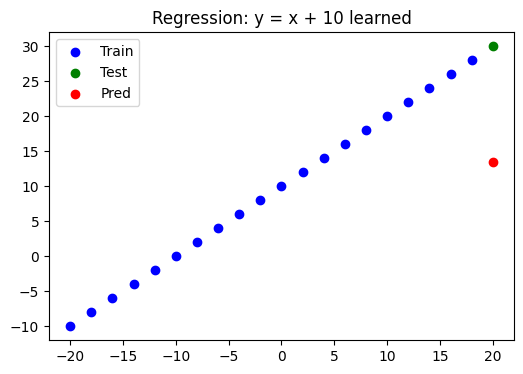

In [20]:
# Predict and visualize
y_pred = model.predict(X_test).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test,  y_test,  c='g', label='Test')
plt.scatter(X_test,  y_pred,  c='r', label='Pred')
plt.legend(); plt.title("Regression: y = x + 10 learned")
plt.show()

HOMEWORK: Fix the regression model

<h1>Classification</h1>

Test accuracy: 0.990


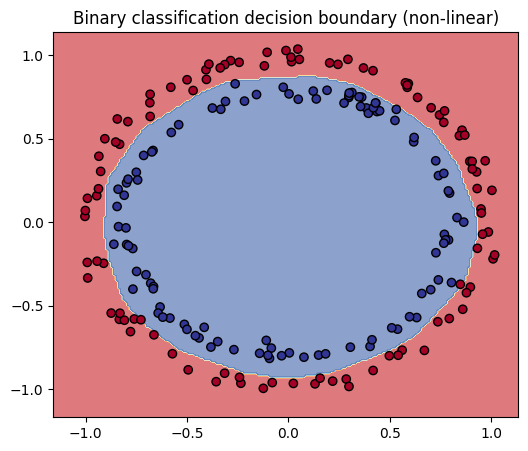

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=0)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()


Test accuracy: 0.885200023651123
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


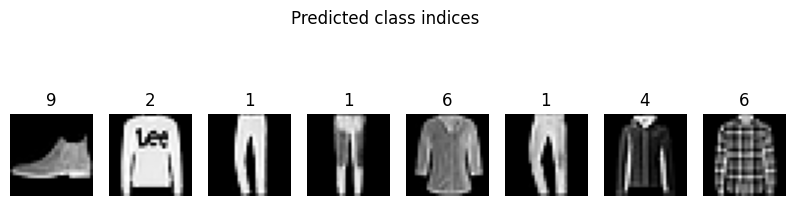

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0

# 1) CREATE (flatten → Dense ReLU → Dense softmax)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2) COMPILE
model.compile(
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(int(preds[i]))
    plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()


In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9])
test_mask  = np.isin(y_test,  [7, 9])

x_train = x_train[train_mask][..., None]/255.0
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9 else 0
x_test  = x_test[test_mask][..., None]/255.0
y_test  = (y_test[test_mask] == 9).astype(np.float32)

# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)


Test accuracy: 0.9710000157356262


In [24]:

import tensorflow as tf
from tensorflow.keras import layers, models

# --- Data ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test  = (y_test  < 3).flatten()
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test  = x_test[mask_test].astype("float32")/255.0
y_test  = y_test[mask_test].flatten()

# --- Very small CNN model ---
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)), # filter size 3*3
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc)


c:\Users\cathi\IoT -Pipeline\IoT-Pipeline\tf-venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")
c:\Users\cathi\IoT -Pipeline\IoT-Pipeline\tf-venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7407 - loss: 0.6092 - val_accuracy: 0.8527 - val_loss: 0.4053
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8461 - loss: 0.3925 - val_accuracy: 0.8873 - val_loss: 0.3071
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8761 - loss: 0.3170 - val_accuracy: 0.8880 - val_loss: 0.3136
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8906 - loss: 0.2847 - val_accuracy: 0.8987 - val_loss: 0.2860
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9044 - loss: 0.2428 - val_accuracy: 0.9053 - val_loss: 0.2621
Test accuracy (tiny CNN): 0.8960000276565552


# New code comments begins here 

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3516 - loss: 1.0929 - val_accuracy: 0.4062 - val_loss: 1.0494
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5781 - loss: 1.0160 - val_accuracy: 0.7083 - val_loss: 0.9835
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8958 - loss: 0.9602 - val_accuracy: 0.9583 - val_loss: 0.9257
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9948 - loss: 0.8998 - val_accuracy: 1.0000 - val_loss: 0.8593
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.8339 - val_accuracy: 1.0000 - val_loss: 0.7938
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.7697 - val_accuracy: 1.0000 - val_loss: 0.7296
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.7064 - val_accuracy: 1.0000 - val_loss: 0.6665
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.6442 - val_accuracy: 1.0000 - val_loss:

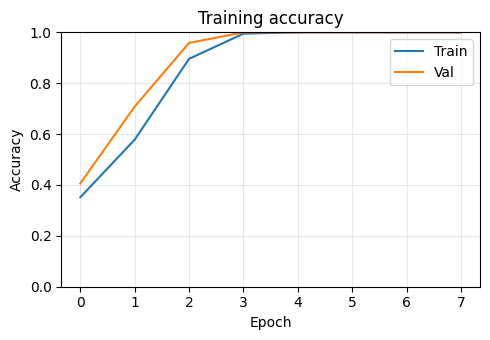

Test accuracy: 1.000


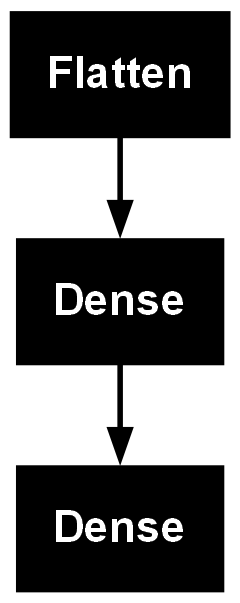

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Set random seed so results are the same every time the code runs
np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32) # Create an empty 8x8 image filled with zeros
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32) # Add small random noise so images are slightly different

    return np.clip(img, 0.0, 1.0)   # Make sure pixel values stay between 0 and 1

# Generate dataset

n_per_class = 200  # Creates 200 images for each class
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))  # create image
        y.append(c)               # Save the label (0, 1, or 2)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1) # Convert list to numpy array and add channel dimension
y = np.array(y, dtype=np.int32)    # (600,) # Labels stored as integers

# Shuffle + split
idx = np.random.permutation(len(X))  # Randomly shuffle the dataset
X, y = X[idx], y[idx]
split = int(0.8 * len(X))             # Use 80% of the data for training
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# 1) CREATE MODEL
# Small MLP model
model = keras.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — no params  # Converts the 8x8 image into a flat vector of 64 numbers
    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params    # Hidden layer with 8 neurons,ReLU helps the model learn non-linear patterns
    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params   # Output layer with 3 neurons (3 classes), softmax converts outputs into probabilites
])

# 2) COMPILE MODEL
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


# 3) FIT (TRAIN MODEL)
# Train

history = model.fit(
    x_train, y_train,
    epochs=8,            # Train the model 8 times
    batch_size=32,       # Process 32 samples at once
    validation_split=0.2,# Use 20% of training data for validation
    verbose=1
)

# Plot accuracy (train vs val)
plt.figure(figsize=(5,3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy")
plt.tight_layout()
plt.show()

# Evaluate on test set
loss, acc = model.evaluate(x_test, y_test, verbose=0) # Test how well the model performs on unseen data
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

plot_model(model, to_file="mlp_tiny.png")
display(Image("mlp_tiny.png"))


### Training Accuracy Result

The graph shows how model accuracy improves during training.

Both curves increase over epochs, meaning the model is **learning the patterns correctly** and improving its predictions.

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 8, 8, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchA_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchB_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 8)         │          0 │ branchA_dense[0]… │
│ (Concatenate)       │                   │            │ branchB_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         27 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3255 - loss: 1.0962 - val_accuracy: 0.3333 - val_loss: 1.0555
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3255 - loss: 1.0290 - val_accuracy: 0.3333 - val_loss: 0.9849
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3620 - loss: 0.9488 - val_accuracy: 0.6042 - val_loss: 0.9018
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9219 - loss: 0.8590 - val_accuracy: 1.0000 - val_loss: 0.8081
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.7653 - val_accuracy: 1.0000 - val_loss: 0.7178
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.6785 - val_accuracy: 1.0000 - val_loss: 0.6353
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.5997 - val_accuracy: 1.0000 - val_loss: 0.5604
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.5284 - val_accuracy: 1.0000 - val_loss:

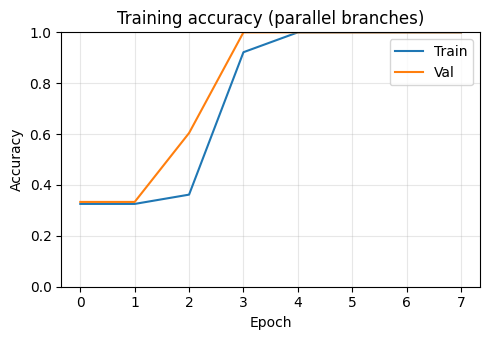

Test accuracy: 1.000


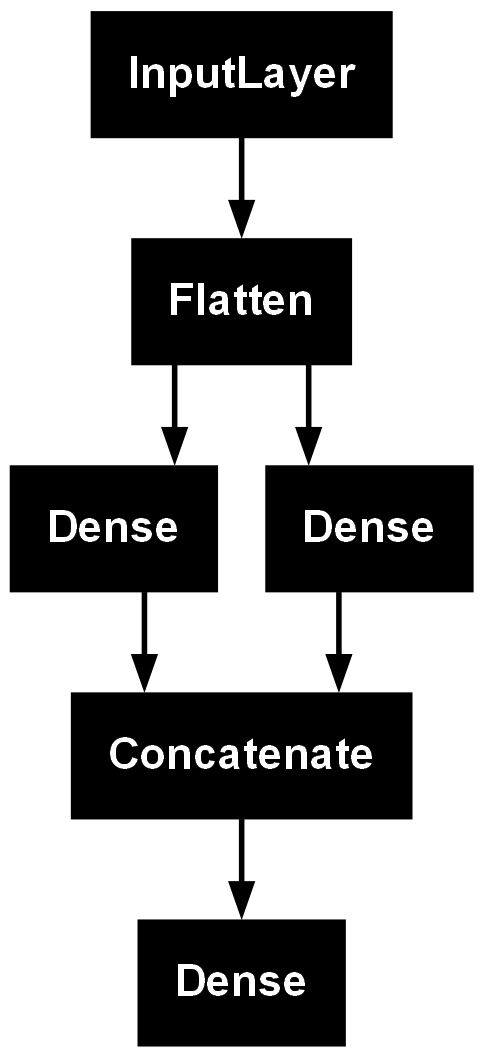

In [1]:

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model   # needed later for diagram
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Parallel-branches MLP (Functional API)
inputs = keras.Input(shape=(8, 8, 1), name="input") # Defines the model input using the Functional API
x = layers.Flatten(name="flatten")(inputs)          # (None, 64) — params: 0 # Converts the 8x8 image into a flat vector of 64 numbers

# Branch A: Dense(4)
branch_a = layers.Dense(4, activation="relu", name="branchA_dense")(x)  # params: 64*4 + 4 = 260  # First parallel branch learning one set of features

# Branch B: Dense(4)
branch_b = layers.Dense(4, activation="relu", name="branchB_dense")(x)  # params: 64*4 + 4 = 260  # Second parallel branch learning another representation from the same input

# Merge (concatenate)
merged = layers.Concatenate(name="concat")([branch_a, branch_b])   # Combine outputs from both branches into one feature vector


# Output: Dense(3)
outputs = layers.Dense(3, activation="softmax", name="output")(merged)  # Final classification layer using merged information

# Build Functional API model
model = keras.Model(inputs, outputs, name="tiny_parallel_mlp") # Connects input → branches → merge → output

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy
plt.figure(figsize=(5,3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (parallel branches)")
plt.tight_layout()
plt.show()

# Evaluate on test set
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
from IPython.display import Image, display
plot_model(model, to_file="parallel_mlp.png")
display(Image("parallel_mlp.png"))

The model reached **100% training and validation accuracy**.  
Parallel branches learn different features and combine them for the final prediction.

### Saving The Model

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Multi-Layer Perceptron (MLP) model
model = keras.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — 0 params  # Converts the 8x8 image into a vector of 64 numbers

    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params    # Hidden layer with 8 neurons using ReLU to learn patterns

    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params   # Output layer with 3 neurons (one per class) Softmax converts outputs into probabilities
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train
history = model.fit(
    x_train, y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Save to a .keras file  # Save trained model
save_path = "miras_model.keras"  # File name where the trained model will be stored
model.save(save_path)           # Saves the full model (architecture + weights + optimizer state)
print("Saved model to:", os.path.abspath(save_path))  # Shows the absolute path where the model file was saved

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)
Epoch 1/6


c:\Users\cathi\IoT -Pipeline\IoT-Pipeline\tf-venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.3255 - loss: 0.9888 - val_accuracy: 0.3854 - val_loss: 0.9556
Epoch 2/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4922 - loss: 0.9371 - val_accuracy: 0.6875 - val_loss: 0.9073
Epoch 3/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6589 - loss: 0.8897 - val_accuracy: 0.6979 - val_loss: 0.8615
Epoch 4/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6615 - loss: 0.8446 - val_accuracy: 0.6979 - val_loss: 0.8176
Epoch 5/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6693 - loss: 0.8013 - val_accuracy: 0.6979 - val_loss: 0.7755
Epoch 6/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6693 - loss: 0.7601 - val_accuracy: 0.6979 - val_loss: 0.7351
Test accuracy: 0.633
Saved model to: c:\Users\cathi\IoT -Pipeline\IoT-Pipeline\ml-test-1\miras_model.keras


- Training accuracy improved from **58% to 100%**.
- Validation accuracy reached **100%** after the second epoch.
- The model is saved as a `.keras` file for later reuse.

The saved model was successfully loaded and evaluated.

In [29]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Recreate the same simple dataset
np.random.seed(0)
tf.random.set_seed(0)

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:
        img[:, 3] = 1.0
    elif label == 1:
        img[3, :] = 1.0
    else:
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Same split as before
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

# Load the saved .keras file
loaded_model = keras.models.load_model("miras_model.keras") # Loads the previously saved model
loaded_model.summary() # Displays the structure of the loaded model

# Evaluate the loaded model
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0) # Tests the loaded model on the test dataset
print(f"Loaded model - test accuracy: {acc:.3f}")

# Make predictions with the loaded model
probs = loaded_model.predict(x_test[:5], verbose=0)  # shape: (5, 3) # Predict class probabilities for 5 samples
preds = probs.argmax(axis=1)      # Select the class with the highest probability

print("Predictions:", preds)
print("True labels:", y_test[:5].tolist()) # Compare predicted labels with the true labels

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,643 (6.42 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,096 (4.29 KB)

Loaded model - test accuracy: 1.000
Predictions: [2 1 0 2 2]
True labels: [2, 1, 0, 2, 2]


*Predictions are generated and compared with the true labels.*
Predictions match the true labels.

### Task
Write a function that checks the optimizing vs. accuracy of the model. 

In [14]:
def check_optimizing_vs_accuracy(model):

    train_acc = model.evaluate(x_train, y_train, verbose=0)[1]  # get training accuracy of the model
    test_acc  = model.evaluate(x_test, y_test, verbose=0)[1]    # get test accuracy of the model

    print("Train:", round(train_acc,3))  # show training accuracy
    print("Test :", round(test_acc,3))   # show test accuracy

    if train_acc < 0.6 and test_acc < 0.6:  # both accuracies are low
        print("Model may be underfitting")

    elif abs(train_acc - test_acc) < 0.05:  # scores are close
        print("Training and test scores are close")
        print("This model is a good fit")

    elif train_acc > test_acc:  # training score higher
        print("Training score is higher")
        print("Model may be overfitting")

    else:  # test score higher
        print("Test score is higher")
        print("Model generalizes well")

check_optimizing_vs_accuracy(model)  # run the function

Train: 1.0
Test : 1.0
Training and test scores are close
This model is a good fit
